# The 95% Illusion: Arctic Temperature Tail Risk

**Article:** [The 95% Illusion: Why the Normal Distribution Almost Killed Me](https://beyondcorrelation1.substack.com/p/the-95-illusion-why-the-normal-distribution)

This notebook reproduces the **Technical Appendix** simulation from the article using SMHI hourly air-temperature data for **Överkalix-Svartbyn A** (station 172770), February **2011–2025**.

Run top-to-bottom to print the survival-risk comparison and the Normal vs. Gumbel plot from the post.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import norm, gumbel_l

# Load SMHI data (Överkalix-Svartbyn A, station 172770)
df = pd.read_csv("smhi-data.csv", sep=";", skiprows=9)
df["Datum"] = pd.to_datetime(df["Datum"])
df["Lufttemperatur"] = pd.to_numeric(df["Lufttemperatur"], errors="coerce")

# February observations, last 15 complete years in the article (2011-2025)
feb_df = df[df["Datum"].dt.month == 2].dropna(subset=["Lufttemperatur"])
data = feb_df[feb_df["Datum"].dt.year.between(2011, 2025)]["Lufttemperatur"].values

mu, std = np.mean(data), np.std(data)
target_temp = -30

prob_actual = np.mean(data <= target_temp)
prob_normal = norm.cdf(target_temp, mu, std)
loc_g, scale_g = gumbel_l.fit(data)
prob_gumbel = gumbel_l.cdf(target_temp, loc_g, scale_g)

# One-sided 95% "worst case" bound (5th percentile of a Normal model)
ci95_lower = mu - 1.645 * std

print(f"February mean (2011-2025): {mu:.2f}°C")
print(f"Std. dev.: {std:.2f}°C")
print(f"Normal 95% lower bound (one-sided): {ci95_lower:.1f}°C")
print()
print(f"Observed frequency at or below {target_temp}°C: {prob_actual:.2%}")
print(f"Normal distribution prediction: {prob_normal:.2%}")
print(f"Gumbel distribution prediction: {prob_gumbel:.2%}")


February mean (2011-2025): -9.32°C
Std. dev.: 8.61°C
Normal 95% lower bound (one-sided): -23.5°C

Observed frequency at or below -30°C: 1.97%
Normal distribution prediction: 0.81%
Gumbel distribution prediction: 2.62%


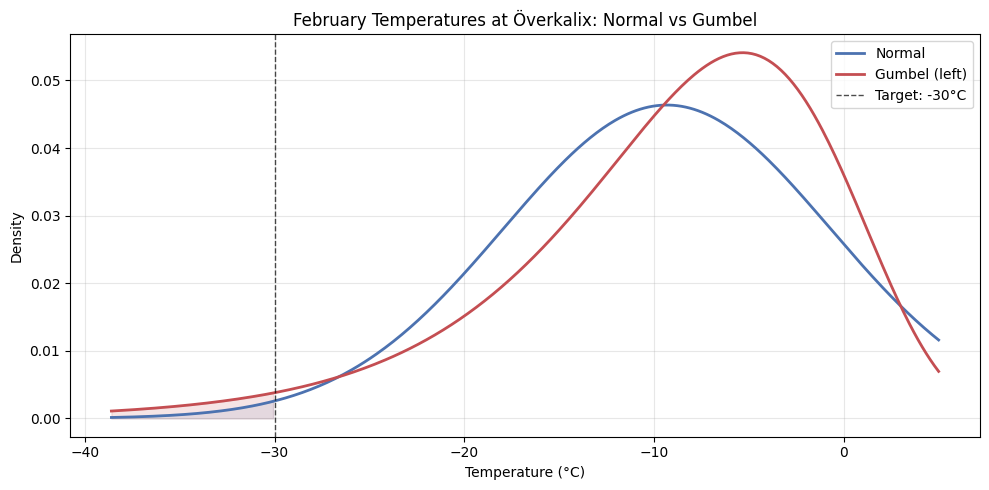

In [2]:
# Normal vs Gumbel comparison (article figure)
x = np.linspace(data.min() - 2, 5, 400)
pdf_normal = norm.pdf(x, mu, std)
pdf_gumbel = gumbel_l.pdf(x, loc_g, scale_g)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, pdf_normal, color="#4C72B0", lw=2, label="Normal")
ax.plot(x, pdf_gumbel, color="#C44E52", lw=2, label="Gumbel (left)")
ax.axvline(target_temp, color="black", ls="--", lw=1, alpha=0.7, label=f"Target: {target_temp}°C")
ax.fill_between(x, 0, pdf_gumbel, where=(x <= target_temp), color="#C44E52", alpha=0.15)
ax.fill_between(x, 0, pdf_normal, where=(x <= target_temp), color="#4C72B0", alpha=0.10)
ax.set_title("February Temperatures at Överkalix: Normal vs Gumbel")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Takeaway

At −30°C the Normal model puts the risk near **0.8%**; reality was about **2%** and the Gumbel model lands near **2.6%** — a conservative margin when missing the tail is dangerous.
